# Análise de Dados: Do Conceito à Prática

Bem-vindos! Antes de mergulharmos nos gráficos e tabelas, vamos entender **o que é** análise de dados e **quais ferramentas** vamos usar.

## 1. Por que e como fazer Análise de Dados?

A análise de dados é o processo de transformar dados "crus" em informações úteis para apoiar a **tomada de decisões**. Em vez de agir por intuição ("eu acho que o problema é no aplicativo"), usamos evidências ("os dados mostram que 80% das falhas estão no aplicativo").

O processo geralmente segue alguns passos:
1. **Definição do Problema:** O que queremos descobrir?
2. **Coleta e Limpeza:** Pegar os dados e arrumar a "sujeira" (valores faltando, duplicados).
3. **Exploração (EDA):** Usar estatística básica e gráficos para entender o que os dados estão nos dizendo.
4. **Comunicação:** Traduzir os números em uma história clara para a gestão.

## 2. Nossas Ferramentas: Pandas e Matplotlib

Para fazer tudo isso no Python, usamos duas bibliotecas principais:

*   **Pandas:** É como um "Excel superpoderoso". Ele nos permite carregar tabelas (chamadas de `DataFrames`), filtrar linhas, criar novas colunas, calcular médias e agrupar dados de forma muito rápida.
*   **Matplotlib:** É a nossa ferramenta de desenho. Com ela, pegamos os números do Pandas e transformamos em gráficos de barras, linhas, pizzas e dispersão, tornando os padrões visíveis aos olhos.

Agora que sabemos o básico, vamos ao nosso caso prático!


---
# Caso prático: falhas em operações digitais

Material para **alunos iniciantes**: o foco está em **ler gráficos**, entender **por que** cada tipo de gráfico existe e **que respostas** você já consegue dar para uma gestão **sem** precisar de modelo preditivo.

No **final**, há um modelo bem curto só como **extra** (ideia geral do que é “preditivo”).

Os números são **fictícios** (semente fixa `42`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

RNG = np.random.default_rng(42)


## 3. O problema (em uma frase)

**Situação de exemplo:** as falhas em operações digitais **preocupam** a equipe.

Antes de qualquer gráfico, combine com a gestão: *o que seria uma boa notícia ao final da análise?* (Ex.: “saber em qual canal investir primeiro”.)


## 4. Que respostas a análise de dados pode dar? (sem modelo)

Com **tabelas e gráficos** você já costuma responder coisas como:

| Tipo de resposta | Exemplo de pergunta |
|------------------|---------------------|
| **Tamanho** | Quantas operações temos? Quantas falharam? |
| **Mix** | O tráfego vem mais do app, da web ou da API? |
| **Comparação** | Em qual grupo a **taxa** de falha é maior? (não confundir com “mais volume”) |
| **Tempo** | A taxa de falha **oscila** ao longo do dia ou da semana? |
| **Prioridade** | Onde vale **olhar primeiro** com time técnico ou de produto? |

O **modelo preditivo** aparece só no fim: é um apoio, não o centro da história para quem está começando.


## 5. Por onde começar (ordem sugerida para iniciantes)

1. Entender o que cada **coluna** significa.
2. **Contar** (números absolutos).
3. Ver **um gráfico por vez** e anotar o que chama atenção.
4. Comparar **taxas** (percentual de falha em cada grupo).
5. Só então fechar um **texto de recomendações** para a gestão.
6. (Opcional) Ver o modelo no último capítulo.


### 5.1 O que cada coluna representa

| Coluna | Significado simples |
|--------|---------------------|
| `data_hora` | data e hora da operação |
| `hora` | hora do dia (0 a 23) |
| `canal` | app, web ou api |
| `tipo_operacao` | pix, ted, boleto ou cartao |
| `perfil_cliente` | rótulo agregado (não identifica pessoa) |
| `valor` | valor da operação |
| `tempo_resposta_ms` | tempo até a resposta (milissegundos) |
| `falhou` | 0 = deu certo, 1 = falhou |


In [2]:
n = 6_000

canal = RNG.choice(["app", "web", "api"], size=n, p=[0.52, 0.33, 0.15])
tipo_operacao = RNG.choice(
    ["pix", "ted", "boleto", "cartao"], size=n, p=[0.44, 0.22, 0.18, 0.16]
)
perfil_cliente = RNG.choice(
    ["estavel", "novo", "inativo"], size=n, p=[0.55, 0.28, 0.17]
)
valor = np.clip(RNG.lognormal(mean=4.0, sigma=1.1, size=n), 5.0, 80_000.0)

base_dia = pd.Timestamp("2025-01-01")
offset_horas = RNG.integers(0, 24 * 40, size=n)
data_hora = pd.to_datetime(base_dia) + pd.to_timedelta(offset_horas, unit="h")
hora = (offset_horas % 24).astype(int)

logit = -2.2
logit += np.select(
    [canal == "web", canal == "api"],
    [0.85, 0.35],
    default=0.0,
)
logit += np.select(
    [tipo_operacao == "cartao", tipo_operacao == "boleto"],
    [0.65, 0.25],
    default=0.0,
)
logit += np.where(perfil_cliente == "novo", 0.45, 0.0)
logit += np.where((hora >= 17) & (hora <= 20), 0.4, 0.0)
logit += 0.15 * (valor / valor.mean() - 1.0)

p_falha = 1 / (1 + np.exp(-logit))
p_falha = np.clip(p_falha + RNG.normal(0, 0.04, size=n), 0.02, 0.75)

falhou = RNG.binomial(1, p_falha)

tempo_ms = RNG.normal(420, 130, size=n)
tempo_ms = np.where(falhou == 1, tempo_ms + RNG.normal(750, 220, size=n), tempo_ms)
tempo_ms = np.clip(tempo_ms, 40.0, 14_000.0)

df = pd.DataFrame(
    {
        "data_hora": data_hora,
        "hora": hora,
        "canal": canal,
        "tipo_operacao": tipo_operacao,
        "perfil_cliente": perfil_cliente,
        "valor": valor.round(2),
        "tempo_resposta_ms": tempo_ms.round(0),
        "falhou": falhou,
    }
)

df.head(10)


,data_hora,hora,canal,tipo_operacao,perfil_cliente,valor,tempo_resposta_ms,falhou
0,2025-01-27 21:00:00,21,web,ted,estavel,62.21,482.0,0
1,2025-01-04 13:00:00,13,app,pix,estavel,17.81,603.0,0
2,2025-02-08 00:00:00,0,api,ted,estavel,467.44,427.0,0
3,2025-01-28 08:00:00,8,web,pix,inativo,417.20,1289.0,1
4,2025-02-03 02:00:00,2,app,pix,estavel,5.58,440.0,0
5,2025-01-16 04:00:00,4,api,ted,estavel,66.32,287.0,0
6,2025-01-08 21:00:00,21,web,ted,estavel,118.66,681.0,0
7,2025-02-02 20:00:00,20,web,cartao,inativo,88.75,559.0,1
8,2025-01-03 01:00:00,1,app,boleto,novo,289.19,421.0,0
9,2025-01-08 07:00:00,7,app,cartao,estavel,230.07,320.0,0


## 6. Checagem rápida dos dados (preparação)

**Por que fazer isso antes dos gráficos?** Para não contar história errada: se metade dos valores estiver vazia ou tudo for duplicado, os gráficos enganam.

**O que esperamos:** poucos ou zero nulos, poucas duplicatas, tipos de dados coerentes (`falhou` numérico 0/1, datas válidas).


In [3]:
df.info()
print()
print("Linhas duplicadas:", df.duplicated().sum())
print("Valores ausentes por coluna:")
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   data_hora          6000 non-null   datetime64[ns]
 1   hora               6000 non-null   int64         
 2   canal              6000 non-null   object        
 3   tipo_operacao      6000 non-null   object        
 4   perfil_cliente     6000 non-null   object        
 5   valor              6000 non-null   float64       
 6   tempo_resposta_ms  6000 non-null   float64       
 7   falhou             6000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 375.1+ KB

Linhas duplicadas: 0
Valores ausentes por coluna:
data_hora            0
hora                 0
canal                0
tipo_operacao        0
perfil_cliente       0
valor                0
tempo_resposta_ms    0
falhou               0
dtype: int64


## 7. Números básicos (antes dos gráficos)

**Por que começar com números?** Porque na apresentação você diz em 10 segundos: “temos X operações e Y% de falha”.

**O que esperamos:** uma ideia clara do **tamanho** do problema (volume) e da **gravidade** (percentual de falha).


In [4]:
print("Total de operações:", len(df))
print()
print("Contagem de falhou (0 = ok, 1 = falhou):")
print(df["falhou"].value_counts().sort_index())
print()
print("Taxa de falha no conjunto todo:", round(100 * df["falhou"].mean(), 1), "%")


Total de operações: 6000

Contagem de falhou (0 = ok, 1 = falhou):
falhou
0    4814
1    1186
Name: count, dtype: int64

Taxa de falha no conjunto todo: 19.8 %


### Gráfico 1 — Barras: quantas operações por **canal** (usando Matplotlib)

**Por que usar gráfico de barras aqui?** Porque `canal` é uma **categoria** (app, web, api). Barras comparam **quantidades** de forma imediata. Usamos a função `plt.bar()` do Matplotlib.

**O que esperamos ver:** qual canal “pesa” mais no volume total. **Atenção:** canal com **mais operações** não é necessariamente o que **mais falha em %** — por isso depois olhamos a taxa de falha separadamente.


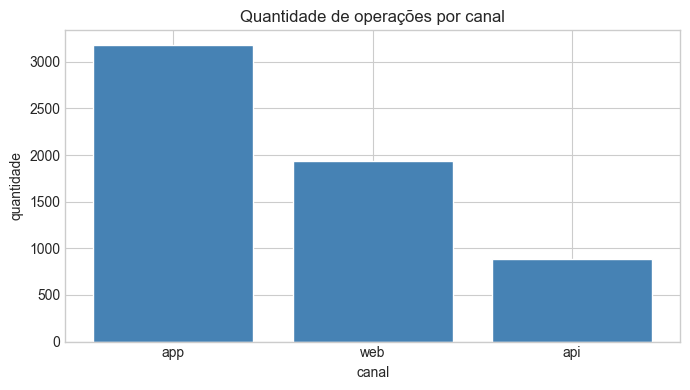

In [5]:
contagem = df["canal"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(contagem.index.astype(str), contagem.values, color="steelblue", edgecolor="white")
plt.title("Quantidade de operações por canal")
plt.xlabel("canal")
plt.ylabel("quantidade")
plt.tight_layout()
plt.show()


### Gráfico 2 — Barras: quantas operações por **tipo**

**Por que usar barras de novo?** Mesma lógica: `tipo_operacao` é categórico.

**O que esperamos:** ver se o problema está concentrado em um tipo (ex.: muito “cartao”) ou se o mix é equilibrado. Isso ajuda a explicar para negócio **de onde vem o trabalho**.


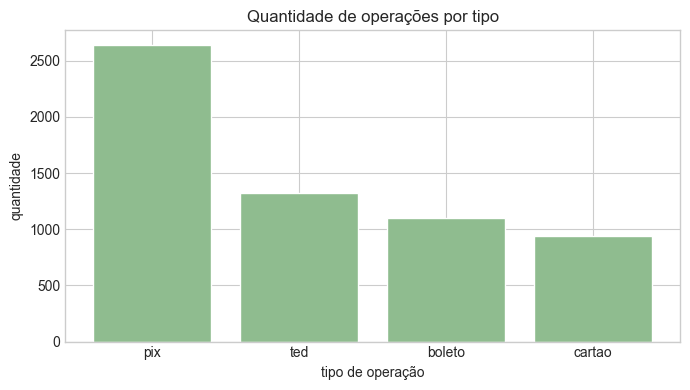

In [6]:
contagem = df["tipo_operacao"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(contagem.index.astype(str), contagem.values, color="darkseagreen", edgecolor="white")
plt.title("Quantidade de operações por tipo")
plt.xlabel("tipo de operação")
plt.ylabel("quantidade")
plt.tight_layout()
plt.show()


### Gráfico 3 — Gráfico de Pareto (Regra 80/20) para Tipos de Operação

**Por que usar o Gráfico de Pareto?** É uma ferramenta clássica de negócios. Ele mostra as barras ordenadas do maior para o menor e uma linha que soma as porcentagens. Ajuda a focar no que importa.

**O que esperamos:** descobrir se resolver o problema em apenas 1 ou 2 tipos de operação já elimina a maior parte das falhas (a famosa regra 80/20).


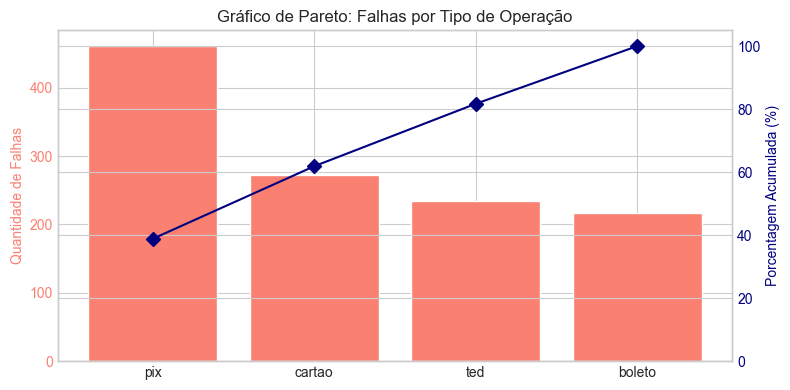

In [7]:
# Filtramos apenas as operações que falharam
falhas = df[df["falhou"] == 1]
contagem_falhas = falhas["tipo_operacao"].value_counts()

# Calculamos a porcentagem acumulada
percentual_acumulado = contagem_falhas.cumsum() / contagem_falhas.sum() * 100

fig, ax1 = plt.subplots(figsize=(8, 4))

# Barras (quantidade de falhas)
ax1.bar(contagem_falhas.index.astype(str), contagem_falhas.values, color="salmon", edgecolor="white")
ax1.set_ylabel("Quantidade de Falhas", color="salmon")
ax1.tick_params(axis="y", labelcolor="salmon")

# Linha (porcentagem acumulada)
ax2 = ax1.twinx()
ax2.plot(contagem_falhas.index.astype(str), percentual_acumulado.values, color="navy", marker="D", ms=7)
ax2.set_ylabel("Porcentagem Acumulada (%)", color="navy")
ax2.tick_params(axis="y", labelcolor="navy")
ax2.set_ylim(0, 105)

plt.title("Gráfico de Pareto: Falhas por Tipo de Operação")
plt.tight_layout()
plt.show()


### Tabela — Média de valor e tempo quando falhou vs não falhou

**Por que uma tabela (e não só gráfico)?** Porque aqui queremos **dois números exatos** para comparar lado a lado.

**O que esperamos:** se “falhou” estiver associado a **tempo maior**, isso vira **pergunta** para o time técnico (“timeout? fila?”). **Não** prova causa sozinha — pode ser efeito da falha — mas orienta conversa.


In [8]:
tabela = df.groupby("falhou")[["valor", "tempo_resposta_ms"]].mean().round(1)
tabela.index = ["não falhou (0)", "falhou (1)"]
display(tabela)


,valor,tempo_resposta_ms
não falhou (0),96.4,416.5
falhou (1),125.4,1156.9


### Gráfico 4 — Barras: média de **tempo de resposta** quando falhou vs não

**Por que transformar a tabela em barras?** Porque para público iniciante o **olho** compara alturas mais rápido que duas linhas de texto.

**O que esperamos:** diferença visível (ou não). Se for grande, anote como **hipótese** para investigação.


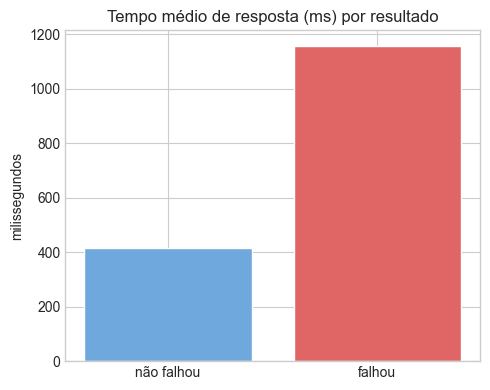

In [9]:
media_tempo = df.groupby("falhou")["tempo_resposta_ms"].mean()
rotulos = ["não falhou", "falhou"]

plt.figure(figsize=(5, 4))
plt.bar(rotulos, media_tempo.values, color=["#6fa8dc", "#e06666"], edgecolor="white")
plt.title("Tempo médio de resposta (ms) por resultado")
plt.ylabel("milissegundos")
plt.tight_layout()
plt.show()


### Gráfico 5 — Histograma: distribuição do **valor** (usando Matplotlib)

**Por que histograma?** Porque `valor` é **numérico contínuo** (muitos valores diferentes). O histograma (`plt.hist()`) mostra se existe **cauda longa** (poucos valores muito altos), se é concentrado perto de zero, etc.

**O que esperamos:** entender se “operações grandes” são raras ou comuns. Isso ajuda a não interpretar uma média “estranha” sem contexto.


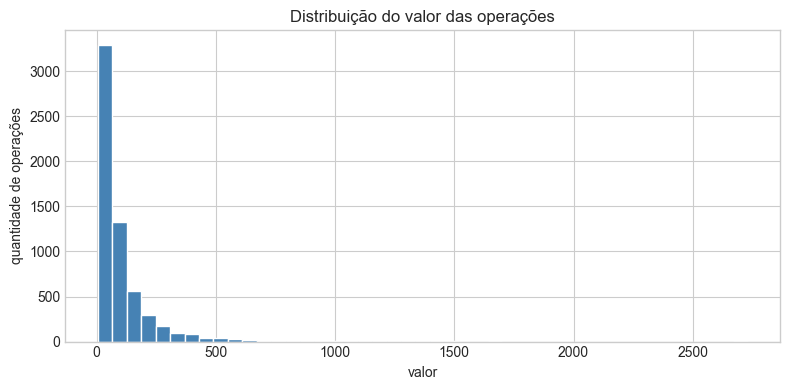

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(df["valor"], bins=45, color="steelblue", edgecolor="white")
plt.title("Distribuição do valor das operações")
plt.xlabel("valor")
plt.ylabel("quantidade de operações")
plt.tight_layout()
plt.show()


### Gráfico 6 — Boxplot: **tempo de resposta** por falhou / não falhou (usando Matplotlib)

**Por que boxplot?** Usando `plt.boxplot()`, ele mostra **mediana**, dispersão e possíveis **valores extremos** (pontos fora do “caixa”).

**O que esperamos:** ver se falhas ocorrem mais quando o tempo fica alto, ou se os tempos se misturam muito (sinal de que o tempo sozinho não explica tudo).


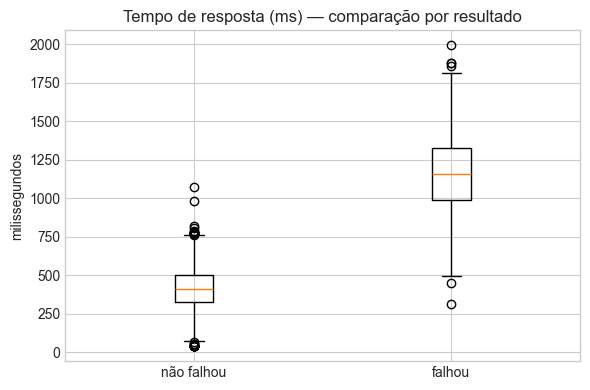

In [11]:
plt.figure(figsize=(6, 4))
plt.boxplot(
    [df.loc[df["falhou"] == 0, "tempo_resposta_ms"], df.loc[df["falhou"] == 1, "tempo_resposta_ms"]],
    tick_labels=["não falhou", "falhou"],
)
plt.title("Tempo de resposta (ms) — comparação por resultado")
plt.ylabel("milissegundos")
plt.tight_layout()
plt.show()


### Gráfico 7 — Linha: taxa de falha por **dia** (usando Matplotlib)

**Por que gráfico de linha?** Porque no eixo X temos **tempo** (dias). Linhas (`plt.plot()`) ajudam a ver **tendência** ou oscilação.

**O que esperamos:** ver se a taxa “sobe e desce” naturalmente ou se há **dias estranhos** (picos) que merecem pergunta: “teve deploy? incidente? feriado?”.


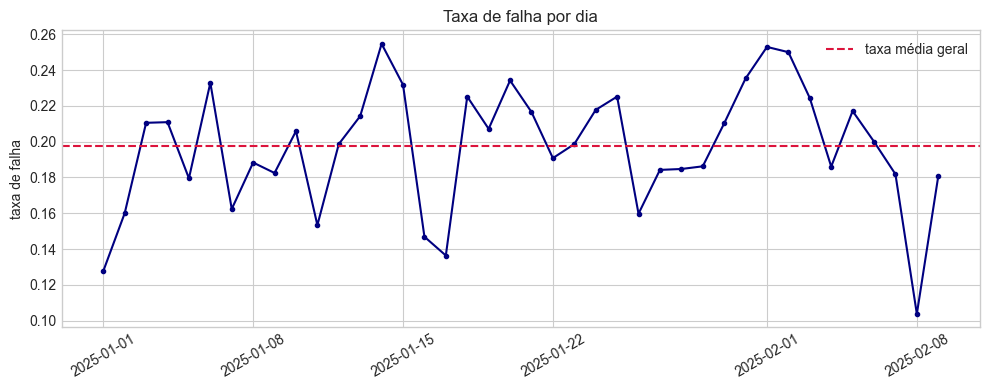

In [12]:
df["dia"] = df["data_hora"].dt.normalize()
taxa_geral = df["falhou"].mean()
por_dia = df.groupby("dia")["falhou"].mean()

plt.figure(figsize=(10, 4))
plt.plot(por_dia.index, por_dia.values, marker=".", color="navy")
plt.axhline(taxa_geral, color="crimson", linestyle="--", label="taxa média geral")
plt.title("Taxa de falha por dia")
plt.ylabel("taxa de falha")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()


### Gráfico 8 — Barras: Taxa de falha por **Dia da Semana**

**Por que olhar o dia da semana?** O comportamento humano muda muito do fim de semana para os dias úteis.

**O que esperamos:** descobrir se o sistema sofre mais de segunda-feira (quando as empresas abrem) ou de domingo (quando há manutenção, por exemplo).


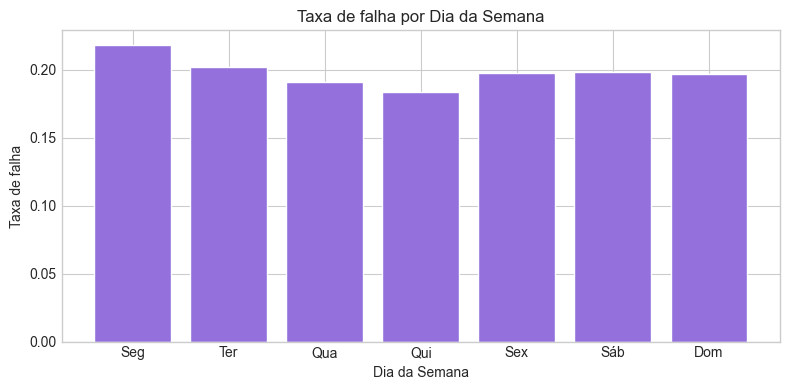

In [13]:
# Pegamos o dia da semana (0=Segunda, 6=Domingo)
df["dia_semana"] = df["data_hora"].dt.dayofweek
nomes_dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

por_dia_semana = df.groupby("dia_semana")["falhou"].mean()

plt.figure(figsize=(8, 4))
plt.bar(por_dia_semana.index, por_dia_semana.values, color="mediumpurple", edgecolor="white")
plt.title("Taxa de falha por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Taxa de falha")
plt.xticks(por_dia_semana.index, [nomes_dias[i] for i in por_dia_semana.index])
plt.tight_layout()
plt.show()


### Gráfico 9 — Linha: taxa de falha por **hora** do dia

**Por que outra linha?** Aqui o tempo é **hora do dia** (0–23). Muitos sistemas têm padrão por **turno** (comercial vs madrugada).

**O que esperamos:** identificar **janelas** (ex.: fim de tarde) para combinar com capacidade, filas ou comportamento do cliente.


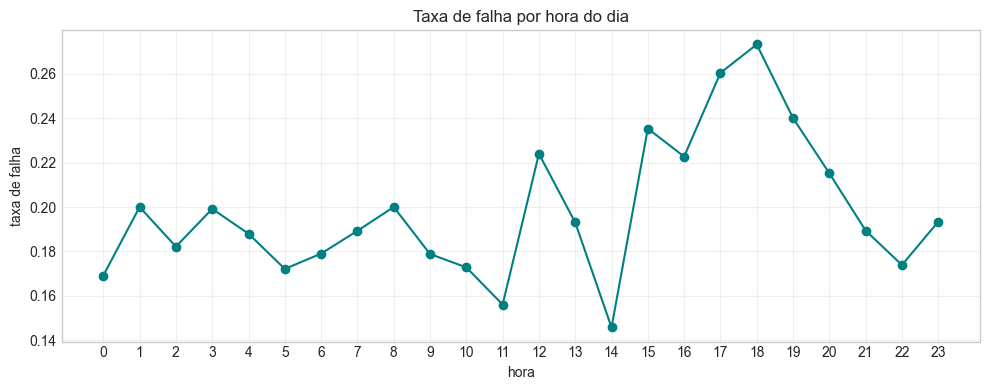

In [14]:
por_hora = df.groupby("hora")["falhou"].mean()

plt.figure(figsize=(10, 4))
plt.plot(por_hora.index, por_hora.values, marker="o", color="teal")
plt.title("Taxa de falha por hora do dia")
plt.xlabel("hora")
plt.ylabel("taxa de falha")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Gráfico 10 — Barras Empilhadas 100%: Proporção de Sucesso vs Falha por **Canal**

**Por que usar barras empilhadas 100%?** Ele preenche a barra até o topo (100%), mostrando visualmente a "fatia" que deu errado dentro de cada canal, independente de um canal ter 1000 operações e o outro ter 10.

**O que esperamos:** ver rapidamente qual canal tem a maior faixa vermelha (falha). É muito intuitivo para apresentações executivas.


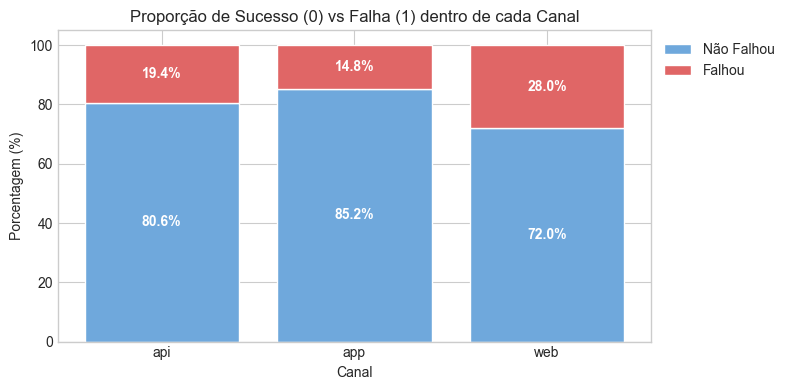

In [15]:
# Criamos uma tabela cruzada com porcentagem por linha
cruzamento = pd.crosstab(df["canal"], df["falhou"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(8, 4))

canais = cruzamento.index.astype(str)
nao_falhou = cruzamento[0].values
falhou = cruzamento[1].values

# Desenhamos a barra de baixo (Não Falhou)
ax.bar(canais, nao_falhou, color="#6fa8dc", edgecolor="white", label="Não Falhou")

# Desenhamos a barra de cima (Falhou), usando 'bottom' para empilhar
ax.bar(canais, falhou, bottom=nao_falhou, color="#e06666", edgecolor="white", label="Falhou")

plt.title("Proporção de Sucesso (0) vs Falha (1) dentro de cada Canal")
plt.xlabel("Canal")
plt.ylabel("Porcentagem (%)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Adicionamos os textos dentro das barras
for i in range(len(canais)):
    if nao_falhou[i] > 5:
        ax.text(i, nao_falhou[i]/2, f"{nao_falhou[i]:.1f}%", ha="center", va="center", color="white", fontweight="bold")
    if falhou[i] > 5:
        ax.text(i, nao_falhou[i] + falhou[i]/2, f"{falhou[i]:.1f}%", ha="center", va="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()


### Gráfico 11 — Pizza: participação de **falhas** no total (usando Matplotlib)

**Por que pizza?** Porque mostra **parte do todo** em porcentagem (fácil de explicar em sala) usando a função `plt.pie()`.

**Cuidado:** pizza perde utilidade com **muitas** fatias; aqui temos só duas (falhou / não falhou), então é aceitável.

**O que esperamos:** ver rapidamente se falhas são “ponta do iceberg” ou uma fatia grande do volume.


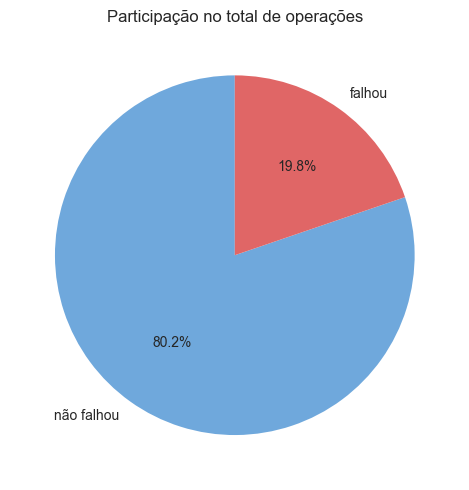

In [16]:
cont = df["falhou"].value_counts().sort_index()
rotulos = ["não falhou", "falhou"]

plt.figure(figsize=(5, 5))
plt.pie(cont.values, labels=rotulos, autopct="%1.1f%%", startangle=90, colors=["#6fa8dc", "#e06666"])
plt.title("Participação no total de operações")
plt.tight_layout()
plt.show()


### Gráfico 12 — Gráfico de Dispersão (Scatter Plot): Valor vs Tempo de Resposta (usando Matplotlib)

**Por que o Scatter Plot?** Ele plota pontos usando duas colunas numéricas (Valor no eixo X, Tempo no eixo Y) através da função `plt.scatter()`. Usamos cores diferentes para Sucesso e Falha.

**O que esperamos:** descobrir se operações de valor muito alto tendem a demorar mais e falhar, ou se as falhas estão espalhadas por todos os valores e tempos. Ajuda a ver "nuvens" de problemas.


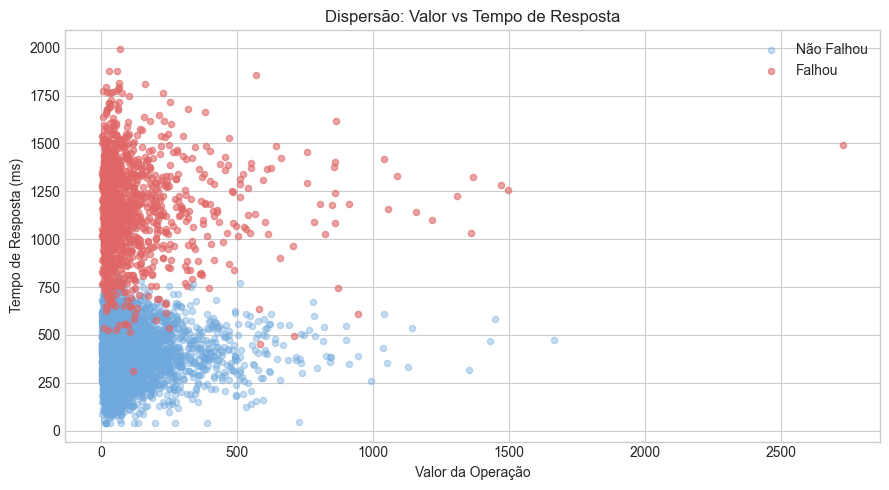

In [17]:
plt.figure(figsize=(9, 5))

# Filtramos os dois grupos
ok = df[df["falhou"] == 0]
falha = df[df["falhou"] == 1]

# Plotamos os que deram certo (azul, mais transparentes)
plt.scatter(ok["valor"], ok["tempo_resposta_ms"], color="#6fa8dc", alpha=0.4, label="Não Falhou", s=20)

# Plotamos os que falharam (vermelho)
plt.scatter(falha["valor"], falha["tempo_resposta_ms"], color="#e06666", alpha=0.6, label="Falhou", s=20)

plt.title("Dispersão: Valor vs Tempo de Resposta")
plt.xlabel("Valor da Operação")
plt.ylabel("Tempo de Resposta (ms)")
plt.legend()
plt.tight_layout()
plt.show()


### Gráfico 13 — Mapa simples: correlação entre números

**Por que olhar correlação?** Para ver se duas medidas numéricas **andam juntas** (ex.: valor vs falha). **Importante:** correlação **não prova causa**.

**O que esperamos:** valores entre -1 e 1 perto de 0 significam “pouca relação linear”; valores mais altos sugerem **investigar** com gráficos e com o time de domínio.


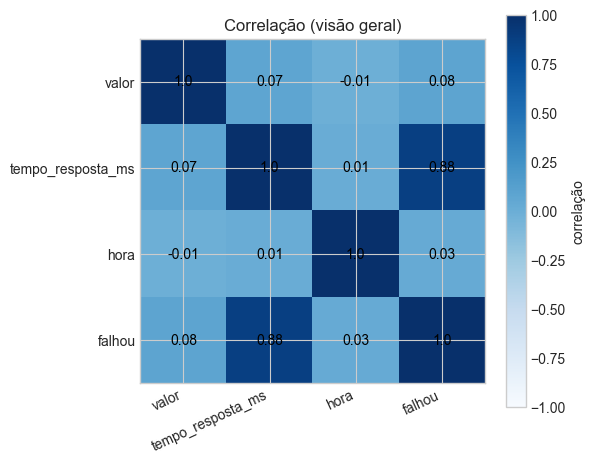

In [18]:
corr = df[["valor", "tempo_resposta_ms", "hora", "falhou"]].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="Blues", vmin=-1, vmax=1)
plt.colorbar(label="correlação")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=25, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center", color="black")
plt.title("Correlação (visão geral)")
plt.tight_layout()
plt.show()


### Gráfico 14 — Mapa de calor: **canal × tipo** (taxa de falha usando Matplotlib)

**Por que esse gráfico?** Porque ele responde: “existe **combinação** (ex.: web + cartão) que está especialmente ruim?”. Usamos `plt.imshow()` para criar o mapa de calor.

**O que esperamos:** células mais escuras (valores maiores) mostram onde vale **aprofundar** primeiro. Ainda é exploratório — confirmação pode exigir logs, testes ou entrevista com especialista.


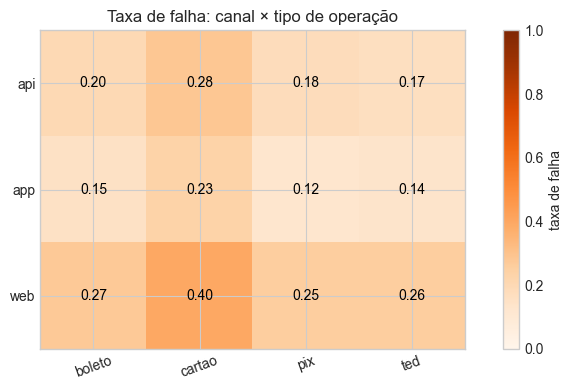

In [19]:
pivot = df.pivot_table(index="canal", columns="tipo_operacao", values="falhou", aggfunc="mean")

plt.figure(figsize=(8, 4))
plt.imshow(pivot, cmap="Oranges", vmin=0, vmax=1)
plt.colorbar(label="taxa de falha")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=20)
plt.yticks(range(len(pivot.index)), pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.iloc[i, j]
        if not np.isnan(v):
            plt.text(j, i, f"{v:.2f}", ha="center", va="center", color="black")
plt.title("Taxa de falha: canal × tipo de operação")
plt.tight_layout()
plt.show()


## 8. Síntese — que respostas você já pode dar **só** com gráficos e tabelas?

Use este bloco como modelo de **roteiro oral** para a gestão (preenchemos com o que os dados mostraram neste recorte):

- **Volume:** de qual canal e tipo vem mais operações? E a regra 80/20 se aplica?
- **Gravidade:** qual é a taxa geral de falha?
- **Onde piora:** qual canal / tipo / perfil / hora tem **maior taxa**?
- **Tempo:** falhas parecem associadas a tempos maiores ou valores maiores?
- **Próximo passo:** qual **um** lugar você recomendaria olhar primeiro amanhã?

> Em dados reais, lembre de **LGPD**, qualidade da coleta e de não confundir **associação** com **causa**.


In [20]:
pior_canal = df.groupby("canal")["falhou"].mean().idxmax()
pior_tipo = df.groupby("tipo_operacao")["falhou"].mean().idxmax()
pior_perfil = df.groupby("perfil_cliente")["falhou"].mean().idxmax()
pior_hora = int(df.groupby("hora")["falhou"].mean().idxmax())
maior_canal_volume = df["canal"].value_counts().idxmax()

print("--- Sugestão de texto para a gestão (exemplo) ---")
print()
print("1) Volume: o canal com mais operações neste arquivo é:", maior_canal_volume)
print("2) Gravidade: taxa geral de falha foi", round(100 * df["falhou"].mean(), 1), "%")
print("3) Onde a taxa piora mais: canal", pior_canal, "| tipo", pior_tipo, "| perfil", pior_perfil)
print("4) Hora com maior taxa neste recorte:", pior_hora, "h")
print("5) Recomendação inicial: priorizar diagnóstico técnico/UX nesses recortes antes de ampliar escopo.")


--- Sugestão de texto para a gestão (exemplo) ---

1) Volume: o canal com mais operações neste arquivo é: app
2) Gravidade: taxa geral de falha foi 19.8 %
3) Onde a taxa piora mais: canal web | tipo cartao | perfil novo
4) Hora com maior taxa neste recorte: 18 h
5) Recomendação inicial: priorizar diagnóstico técnico/UX nesses recortes antes de ampliar escopo.


## 9. (Extra / final) Modelo preditivo bem curto

Para iniciantes, o modelo é só um **exemplo** do tipo “preditivo”: entra algumas colunas e tenta **classificar** se `falhou` será 0 ou 1.

**Por que não colocamos `tempo_resposta_ms` aqui?** Porque no mundo real ele pode ser **efeito** da falha, não causa — o modelo ficaria “bonito” e **enganoso** para decisão.

**O que esperamos:** acerto melhor que chute aleatório, mas sempre com validação e bom senso de negócio.


              precision    recall  f1-score   support

           0      0.805     0.997     0.891      1204
           1      0.600     0.020     0.039       296

    accuracy                          0.804      1500
   macro avg      0.703     0.508     0.465      1500
weighted avg      0.765     0.804     0.723      1500



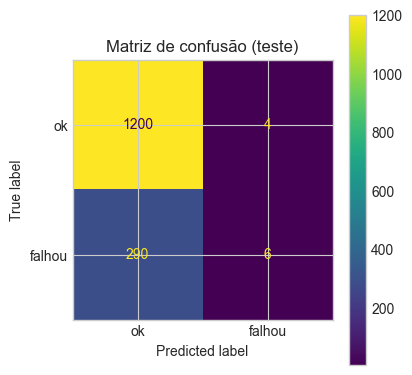

In [21]:
feat = df[["canal", "tipo_operacao", "perfil_cliente", "hora", "valor"]].copy()
X = pd.get_dummies(
    feat,
    columns=["canal", "tipo_operacao", "perfil_cliente"],
    drop_first=False,
)
y = df["falhou"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=300, random_state=42)),
    ]
)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

fig, ax = plt.subplots(figsize=(4.2, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["ok", "falhou"], ax=ax)
ax.set_title("Matriz de confusão (teste)")
plt.tight_layout()
plt.show()
